 **Prediction Sales** involves forecasting the amount of a product that
customers will purchase, taking into account various factors such as
advertising expenditure, target audience segmentation, and
advertising platform selection.

In businesses that offer products or services, the role of a Data
Scientist is crucial for predicting future sales. They utilize machine
learning techniques in Python to analyze and interpret data, allowing
them to make informed decisions regarding advertising costs. By
leveraging these predictions, businesses can optimize their
advertising strategies and maximize sales potential.

Let's embark on the journey of sales prediction using machine learning in Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/content/advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [2]:
print('Dataset shape:',df.shape)

print('\nDataset information')
df.info()

print('\nMissing values:')
print(df.isnull().sum())

print('\nStatistical Summary:')
print(df.describe())

Dataset shape: (200, 4)

Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Statistical Summary:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.6000

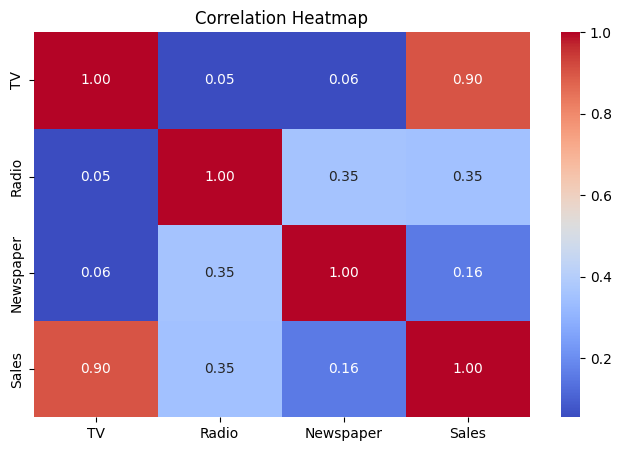

In [5]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


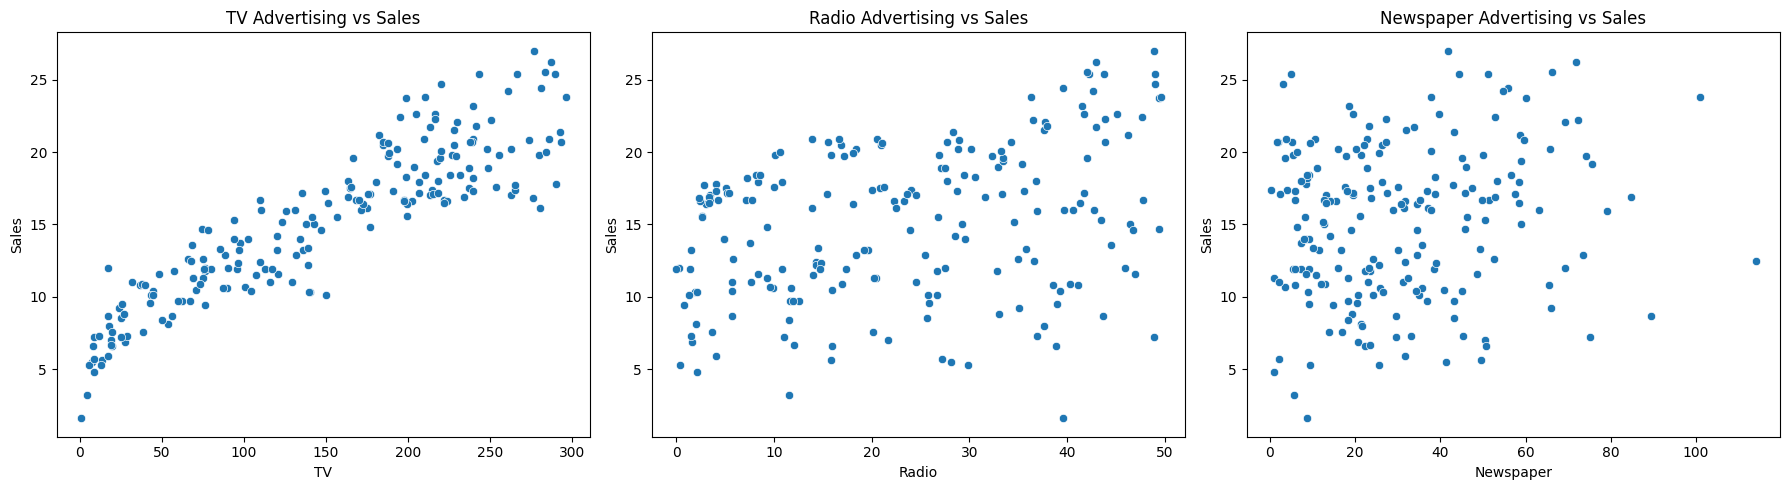

In [6]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
sns.scatterplot(data=df,x='TV',y='Sales',ax=axes[0])
axes[0].set_title('TV Advertising vs Sales')
sns.scatterplot(data=df,x='Radio',y='Sales',ax=axes[1])
axes[1].set_title('Radio Advertising vs Sales')
sns.scatterplot(data=df,x='Newspaper',y='Sales',ax=axes[2])
axes[2].set_title('Newspaper Advertising vs Sales')
plt.tight_layout()
plt.show()

In [7]:
X=df[['TV','Radio','Newspaper']]
y=df['Sales']

print('Features (X): ')
print(X.head())

print('\nTarget (y): ')
print(y.head())

Features (X): 
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target (y): 
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print('Training data shape:',X_train.shape)
print('Testing data shape:',X_test.shape)

Training data shape: (160, 3)
Testing data shape: (40, 3)


In [9]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

print('Model trained successfully')

Model trained successfully


In [10]:
y_pred=model.predict(X_test)
print('Actual Sales:')
print(y_test.head(10).values)
print('Predictions:')
print(y_pred[:10])


Actual Sales:
[16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 16.5 16.1]
Predictions:
[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475]


In [11]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print('Model Evaluation Results:')
print('-------------------------')
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {np.sqrt(mse)}')

Model Evaluation Results:
-------------------------
Mean Absolute Error (MAE): 1.2748262109549338
Mean Squared Error (MSE): 2.9077569102710896
Root Mean Squared Error (RMSE): 1.7052146229349223


In [13]:
r2=r2_score(y_test,y_pred)
print(f'R-squared (R2): {r2:.2%}')


R-squared (R2): 90.59%


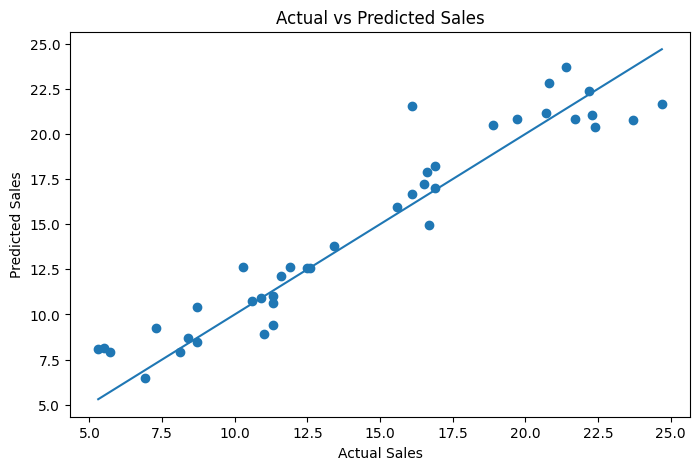

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.show()

In [16]:
import joblib

joblib.dump(model,'sales_prediction_model.pkf')

print('Model saved succcessfully')

Model saved succcessfully


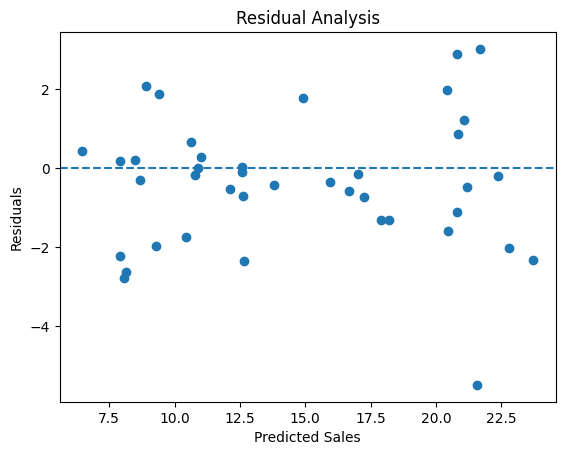

In [17]:
residuals =y_test-y_pred
plt.scatter(y_pred,residuals)
plt.axhline(y=0,linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Analysis')
plt.show()

In [18]:
new_data=pd.DataFrame({'TV':[150],'Radio':[30],'Newspaper':[20]})
predicted_sales=model.predict(new_data)
print(f'Predicted Sales for New Data: {predicted_sales[0]:.2f}')

Predicted Sales for New Data: 16.01


In [19]:
print("SALES PREDICTION PROJECT SUMMARY")
print("--------------------------------")
print("Algorithm Used: Linear Regression")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {np.sqrt(mse):.2f}")
print(f"R-squared Score: {r2:.2%}")
print("Sample Prediction for TV=150, Radio=30, Newspaper=20: 16.01")

SALES PREDICTION PROJECT SUMMARY
--------------------------------
Algorithm Used: Linear Regression
Mean Absolute Error: 1.27
Mean Squared Error: 2.91
Root Mean Squared Error: 1.71
R-squared Score: 90.59%
Sample Prediction for TV=150, Radio=30, Newspaper=20: 16.01


## Conclusion

A Linear Regression model was developed to predict product sales using TV, Radio, and Newspaper advertising expenditure.

The model achieved an R² score of 90.59%, indicating that it explains most of the variation in sales. The evaluation metrics and visualizations show that the model provides reasonably accurate predictions.

The model was also tested on new advertising data and predicted sales of 16.01 units.

Thus, machine learning can be effectively used to estimate sales based on advertising investments.